# Olist E-commerce — Descriptive Analytics

**Dataset:** Olist Brazilian e-commerce (~100k orders, Sep 2016 – Oct 2018).

This notebook computes: (1) top product categories by orders & GMV, (2) repeat-purchase rate and time between orders, and (3) a conversion/quality view (delivered share, review-score distribution). The one-page executive summary is at the top; the fully reproducible analysis follows below.

---
## Executive summary (1 page)

**Headline KPIs**

| KPI | Value | Why it matters |
|---|---|---|
| **Repeat-purchase rate** | **3.1%** of customers order more than once | The single biggest growth lever — the business is almost entirely acquisition-driven |
| Gross Merchandise Value (GMV, items only) | **R$ 13.6M** | Top-line demand; freight adds a further R$ 2.3M |
| Delivered-order share | **97.0%** | Fulfilment reliability is high; cancellations/failures are rare |
| Mean review score | **4.09 / 5** | Overall satisfaction is good but *polarised* (see insight 3) |
| Median time between repeat orders | **28 days** | Repeat demand, when it happens, is monthly-cadence |

**Retention, not acquisition, is the opportunity (detailed in Insights 2–3 below).** Only **3.1%** of the 96,096 unique customers ever place a second order (mean 1.03 orders/customer). Olist has effectively built a one-purchase funnel. Because acquisition is expensive and the base is large, lifting repeat rate even a few points is the highest-leverage move available — a jump from 3% → 6% would roughly double repeat GMV without a single new customer. **Why it matters:** it reframes strategy from "buy more traffic" to "win the second order" (post-purchase CRM, category cross-sell at the ~28-day mark).

**Late delivery is the primary destroyer of review scores (detailed in Insight 4 below).** Reviews are bimodal (57.8% are 5-star, yet 11.5% are 1-star). Splitting delivered orders by whether they beat the *estimated* delivery date explains the tail: on-time orders average **4.29** stars with **6.6%** 1-star, while late orders average **2.57** stars with **46%** 1-star — a **7×** jump in 1-star risk. Late orders are only 8.1% of deliveries but account for a hugely disproportionate share of detractors. **Why it matters:** the review distribution is largely an *operations* metric. Tightening delivery-date estimates and reducing the 8% late rate is the most direct way to move satisfaction and, by extension, repeat rate (the retention opportunity above).

*Recommended next step:* a retention model / post-purchase campaign targeting the ~28-day repeat window, prioritised toward customers whose first order was **on-time** (they are far more likely to return happy).

---
## Reproducible analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Resolve the data directory whether the notebook is run from repo root or notebooks/
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
cat_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

print(f"orders: {orders.shape[0]:,} rows")
print(f"date range: {orders.order_purchase_timestamp.min():%Y-%m-%d} → {orders.order_purchase_timestamp.max():%Y-%m-%d}")

orders: 99,441 rows
date range: 2016-09-04 → 2018-10-17


In [2]:
# --- Prep: English category names, and the true customer identity ---
# NOTE: in Olist, `customer_id` is unique PER ORDER; `customer_unique_id`
# is the real person. Repeat-purchase analysis must use `customer_unique_id`.
products_cat = products.merge(cat_translation, on="product_category_name", how="left")
products_cat["category"] = products_cat["product_category_name_english"].fillna("unknown")

items = order_items.merge(products_cat[["product_id", "category"]], on="product_id", how="left")

orders_c = orders.merge(
    customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left"
)

n_orders = orders_c.order_id.nunique()
n_customers = orders_c.customer_unique_id.nunique()
print(f"unique orders: {n_orders:,}")
print(f"unique customers (customer_unique_id): {n_customers:,}")

unique orders: 99,441
unique customers (customer_unique_id): 96,096


### 1. Top product categories by orders & GMV

GMV is defined as the sum of item `price` (freight excluded — freight adds a further R$ 2.3M). AOV = GMV / distinct orders in the category.

> *Caveat:* GMV is measured at item `price` and is **not** net of cancellations, but only 0.6% of orders are canceled, so the effect is negligible.

In [3]:
cat_rating = (
    items[["order_id", "category"]]
    .drop_duplicates()
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")
    .groupby("category")
    .review_score.mean()
)

cat_stats = (
    items.groupby("category")
    .agg(gmv=("price", "sum"), orders=("order_id", "nunique"), items=("order_item_id", "count"))
    .assign(aov=lambda d: d.gmv / d.orders, avg_rating=lambda d: d.index.map(cat_rating))
    .sort_values("gmv", ascending=False)
)
total_gmv = cat_stats.gmv.sum()
cat_stats["gmv_share_%"] = 100 * cat_stats.gmv / total_gmv

print(f"Total GMV (items only): R$ {total_gmv:,.0f}")
print(f"Total freight:          R$ {items.freight_value.sum():,.0f}")
print(f"Top-3 categories = {cat_stats.head(3)['gmv_share_%'].sum():.1f}% of GMV\n")
cat_stats.head(10).round(1)

Total GMV (items only): R$ 13,591,644
Total freight:          R$ 2,251,910
Top-3 categories = 25.8% of GMV



,gmv,orders,items,aov,avg_rating,gmv_share_%
category,,,,,,
health_beauty,"1,258,681.30",8836,9670,142.40,4.20,9.30
watches_gifts,"1,205,005.70",5624,5991,214.30,4.10,8.90
bed_bath_table,"1,036,988.70",9417,11115,110.10,4.00,7.60
sports_leisure,"988,049.00",7720,8641,128.00,4.20,7.30
computers_accessories,"911,954.30",6689,7827,136.30,4.00,6.70
furniture_decor,"729,762.50",6449,8334,113.20,4.00,5.40
cool_stuff,"635,290.80",3632,3796,174.90,4.20,4.70
housewares,"632,248.70",5884,6964,107.50,4.10,4.70
auto,"592,720.10",3897,4235,152.10,4.10,4.40


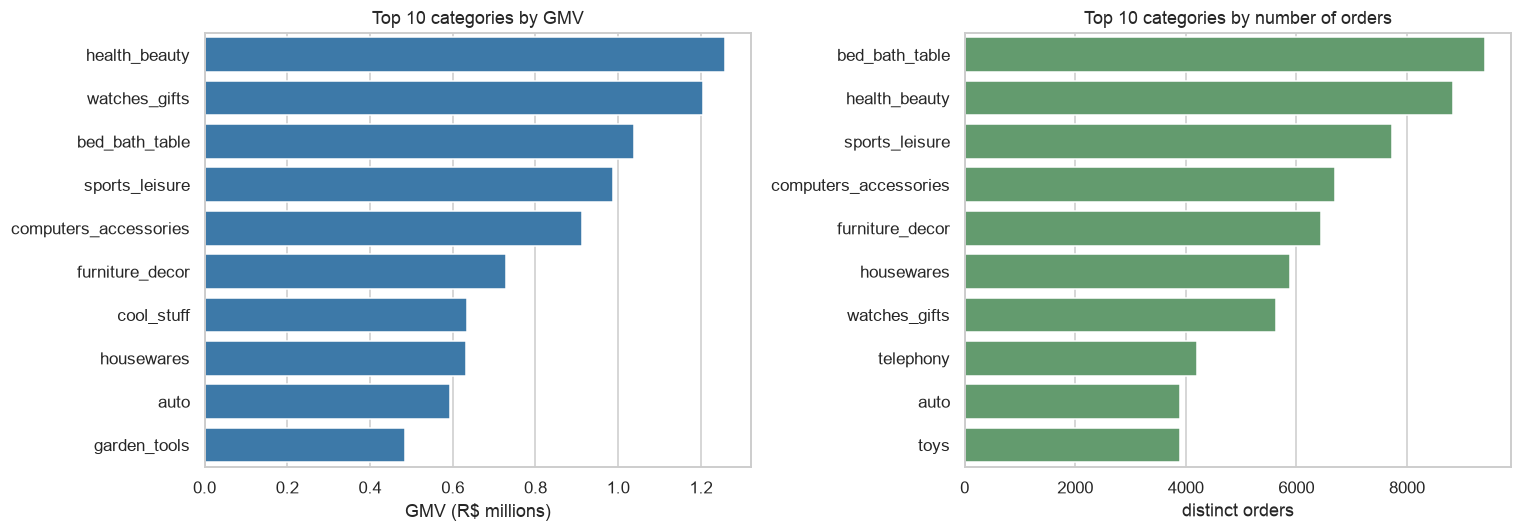

In [4]:
top_gmv = cat_stats.head(10)
top_orders = cat_stats.sort_values("orders", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_gmv.gmv / 1e6, y=top_gmv.index, ax=axes[0], color="#2b7bba")
axes[0].set_title("Top 10 categories by GMV")
axes[0].set_xlabel("GMV (R$ millions)")
axes[0].set_ylabel("")

sns.barplot(x=top_orders.orders, y=top_orders.index, ax=axes[1], color="#5aa469")
axes[1].set_title("Top 10 categories by number of orders")
axes[1].set_xlabel("distinct orders")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [5]:
# Volume vs. value: AOV highlights basket-driven categories
cat_stats["rank_orders"] = cat_stats["orders"].rank(ascending=False).astype(int)
cat_stats["rank_gmv"] = cat_stats["gmv"].rank(ascending=False).astype(int)
aov_view = cat_stats.head(12)[["orders", "rank_orders", "gmv", "rank_gmv", "aov"]].sort_values("rank_gmv")
print("Rank-2-by-GMV `watches_gifts` is only rank-7 by orders → driven by high AOV:\n")
aov_view.round(1)

Rank-2-by-GMV `watches_gifts` is only rank-7 by orders → driven by high AOV:



,orders,rank_orders,gmv,rank_gmv,aov
category,,,,,
health_beauty,8836,2,"1,258,681.30",1,142.40
watches_gifts,5624,7,"1,205,005.70",2,214.30
bed_bath_table,9417,1,"1,036,988.70",3,110.10
sports_leisure,7720,3,"988,049.00",4,128.00
computers_accessories,6689,4,"911,954.30",5,136.30
furniture_decor,6449,5,"729,762.50",6,113.20
cool_stuff,3632,11,"635,290.80",7,174.90
housewares,5884,6,"632,248.70",8,107.50
auto,3897,9,"592,720.10",9,152.10


### Insight 1 - High-AOV categories drive GMV
— GMV is driven by basket value, not just volume.** `watches_gifts` is only the **7th** category by order count but the **2nd** by GMV, because its average order value (**R$ 214**) is ~2× that of high-volume categories like `bed_bath_table` (R$ 110).

**Why it matters:** growth planning should not chase order count alone - steering marketing toward high-AOV categories (watches/gifts, cool_stuff, computers) compounds revenue faster than steering toward high-traffic-but-low-ticket ones.

### 2. Repeat-purchase rate & time between orders

Using `customer_unique_id` as the person — **not** the per-order `customer_id`, which would incorrectly show ~0% repeats. Repeat rate = share of customers with >1 order.

> *Caveat:* the panel is a **snapshot ending Oct 2018**; recent customers have had less time to make a second purchase, so the 3.1% repeat rate is a lower bound.

In [6]:
orders_per_customer = orders_c.groupby("customer_unique_id").order_id.nunique()

repeat_rate = (orders_per_customer > 1).mean()
print(f"KPI — Repeat-purchase rate: {repeat_rate:.1%}")
print(f"Mean orders per customer:   {orders_per_customer.mean():.3f}")
print(f"Repeat customers (>1 order): {(orders_per_customer > 1).sum():,}")
print("\nDistribution of orders per customer:")
orders_per_customer.value_counts().sort_index().head(6).to_frame("customers")

KPI — Repeat-purchase rate: 3.1%
Mean orders per customer:   1.035
Repeat customers (>1 order): 2,997

Distribution of orders per customer:


,customers
order_id,
1,93099
2,2745
3,203
4,30
5,8
6,6


Repeat-order intervals observed: 3,345
Mean time between orders:   77.9 days
Median time between orders: 28 days  (IQR 0-119)
Std dev:                    107.4 days  (CV=1.38, skew=1.72)


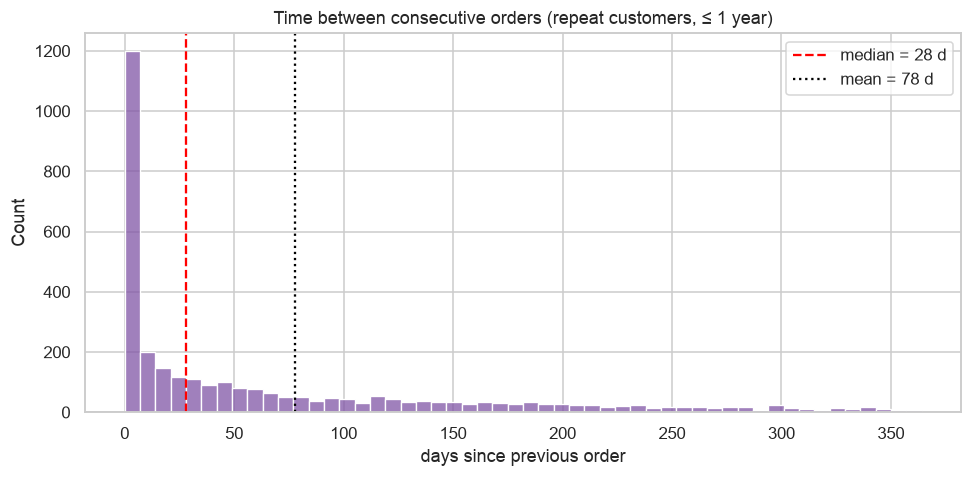

In [7]:
# Time between consecutive orders for repeat customers
seq = orders_c.sort_values(["customer_unique_id", "order_purchase_timestamp"]).copy()
seq["prev_purchase"] = seq.groupby("customer_unique_id").order_purchase_timestamp.shift()
gaps_days = (seq.order_purchase_timestamp - seq.prev_purchase).dt.days.dropna()

# The distribution is heavily right-skewed and over-dispersed
# (std > mean, CV > 1, skew ~ +1.7), so the MEAN is misleading and the
# MEDIAN + IQR is the honest summary. A symmetric mean +/- std would even
# imply negative wait times, which is nonsensical.
q1, q3 = gaps_days.quantile([0.25, 0.75])
print(f"Repeat-order intervals observed: {len(gaps_days):,}")
print(f"Mean time between orders:   {gaps_days.mean():.1f} days")
print(f"Median time between orders: {gaps_days.median():.0f} days  (IQR {q1:.0f}-{q3:.0f})")
print(f"Std dev:                    {gaps_days.std():.1f} days  (CV={gaps_days.std()/gaps_days.mean():.2f}, skew={gaps_days.skew():.2f})")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(gaps_days[gaps_days <= 365], bins=52, color="#8155a6", ax=ax)
ax.axvline(gaps_days.median(), color="red", ls="--", label=f"median = {gaps_days.median():.0f} d")
ax.axvline(gaps_days.mean(), color="black", ls=":", label=f"mean = {gaps_days.mean():.0f} d")
ax.set_title("Time between consecutive orders (repeat customers, ≤ 1 year)")
ax.set_xlabel("days since previous order")
ax.legend()
plt.tight_layout()
plt.show()

### Insight 2 - Average repeat time overstates the typical cadence
Skew = 1.72 — a long tail of large values (customers who come back after many months/a year)
Mean (77.9) ≫ Median (28) — the mean is ~2.8× the median, which only happens when a minority of very long intervals drag the average up
CV = 1.38 (std > mean) — high relative dispersion, so the mean is unstable and not "typical"

**Why it matters:** the honest "typical" repurchase gap is the **median of ~28 days**, not the inflated 78-day mean, so retention actions (reminder emails, replenishment nudges, cross-sell offers) should fire around the **1-month mark** — reinforcing the ~28-day repeat window — rather than being timed off a misleading average. And because the distribution has a long right tail (skew 1.72), a single fixed reorder date will miss the sizeable minority who only return after many months: a multi-touch, decaying cadence beats a one-shot campaign.

Repeat-order intervals observed (>0 days): 2,346
Same-day orders excluded:                  999
Mean time between orders:   111.0 days
Median time between orders: 68 days  (IQR 22-170)
Std dev:                    113.0 days  (CV=1.02, skew=1.34)


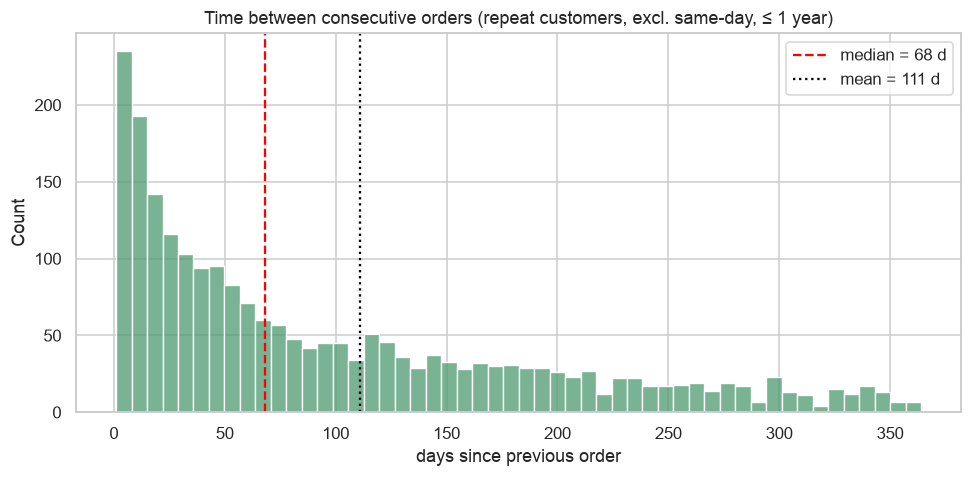

In [8]:
# Same as above, but excluding same-day repeat orders (gap == 0 days).
# A 0-day gap is almost always one purchase split into multiple order_ids,
# not a genuine repurchase, and it drags the 25th percentile to 0.
gaps_days_pos = gaps_days[gaps_days > 0]

q1, q3 = gaps_days_pos.quantile([0.25, 0.75])
print(f"Repeat-order intervals observed (>0 days): {len(gaps_days_pos):,}")
print(f"Same-day orders excluded:                  {(gaps_days == 0).sum():,}")
print(f"Mean time between orders:   {gaps_days_pos.mean():.1f} days")
print(f"Median time between orders: {gaps_days_pos.median():.0f} days  (IQR {q1:.0f}-{q3:.0f})")
print(f"Std dev:                    {gaps_days_pos.std():.1f} days  (CV={gaps_days_pos.std()/gaps_days_pos.mean():.2f}, skew={gaps_days_pos.skew():.2f})")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(gaps_days_pos[gaps_days_pos <= 365], bins=52, color="#4c9a70", ax=ax)
ax.axvline(gaps_days_pos.median(), color="red", ls="--", label=f"median = {gaps_days_pos.median():.0f} d")
ax.axvline(gaps_days_pos.mean(), color="black", ls=":", label=f"mean = {gaps_days_pos.mean():.0f} d")
ax.set_title("Time between consecutive orders (repeat customers, excl. same-day, ≤ 1 year)")
ax.set_xlabel("days since previous order")
ax.legend()
plt.tight_layout()
plt.show()

### Insight 3 - Same-day order splits are not true repurchases
**What we exclude — and why same-day orders are *not* a repurchase.** The chart above drops all **0-day gaps**: 999 of 3,345 repeat-order intervals (~30%) happen on the *same calendar day* as the previous order. These are almost never a customer genuinely coming back — they are one shopping intent that Olist splits into multiple `order_id`s (a separate order is created per seller/shipment at checkout). Counting them as "repurchases" measures order-splitting mechanics, not retention behaviour.

Keeping the zeros badly distorts the signal: they pull the 25th percentile and drag the median down (IQR **0**–119, median **28d**). Once same-day splits are removed, the honest cadence emerges — median jumps to **~68 days** with an IQR of **22–170** — and the distribution is less extreme (skew 1.72 → 1.34).

**Why it matters:** retention and replenishment actions should be timed off *genuine* return trips, not checkout artefacts. A ~28-day median implied by the raw data would fire reminders far too early for most customers; the same-day-excluded view (~2 months) is the more defensible planning horizon. We still keep the 0-day cases *out* of interval analysis but they remain valid *orders* for GMV/volume — the exclusion is specific to "time between purchases".

### 3. Conversion & quality view

Delivered share of all orders, the review-score distribution, and the link between late delivery and bad reviews.

> *Caveat:* **late** = actual delivery after the customer-facing estimated date; ~1.5% of delivered orders lack a delivery date and are treated as on-time.

---
### Open orders — what is still "in the pipeline"?

About **2% of orders never reach `delivered`**. Since the dataset is a **static export ending Oct 2018**, we can ask a supply-chain question: are these *recent* shipments still legitimately in transit, or a **stale backlog**?

We treat the latest purchase timestamp as the *as-of* date and measure, for each open order, how long it has been sitting since its last observed event — starting with `shipped` (handed to the carrier but never delivered), then the same lens for every other non-delivered status.

In [9]:
# Same lens for every non-delivered status: how long has each open order been idle,
# using the last event we can observe (purchase -> approved -> handed to carrier).
# As-of date is derived from the data: the latest purchase timestamp in the export.
as_of = pd.to_datetime(orders.order_purchase_timestamp).max()
nd = orders[orders.order_status != "delivered"].copy()
for c in ["order_approved_at", "order_delivered_carrier_date"]:
    nd[c] = pd.to_datetime(nd[c])
nd["last_event"] = nd[["order_purchase_timestamp", "order_approved_at",
                       "order_delivered_carrier_date"]].max(axis=1)
nd["days_stuck"] = (as_of - nd.last_event).dt.days
nd["overdue"] = as_of > nd.order_estimated_delivery_date

summary = (
    nd.groupby("order_status")
    .agg(
        orders=("order_id", "size"),
        median_days=("days_stuck", "median"),
        max_days=("days_stuck", "max"),
        pct_overdue=("overdue", "mean"),
    )
    .sort_values("orders", ascending=False)
)
summary.assign(
    median_days=lambda d: d.median_days.round(0).astype(int),
    pct_overdue=lambda d: d.pct_overdue.map("{:.0%}".format),
)

,orders,median_days,max_days,pct_overdue
order_status,,,,
shipped,1107,279,736,100%
canceled,625,259,743,99%
unavailable,609,366,741,100%
invoiced,314,335,743,100%
processing,301,392,741,100%
created,5,316,345,100%
approved,2,576,617,100%


**Takeaway:** there is *no* live in-transit backlog. Every open order — `shipped`, `invoiced`, `processing`, `unavailable`, `canceled` — is already **past its promised ETA** and has been idle for a median of **~9 months** (even the freshest `shipped` order is 43 days old). In a static Olist export these behave like **abandoned / never-completed orders**, not shipments awaiting delivery. Practical implication: exclude them from delivery-time SLA and on-time metrics, and treat the volume per status as an **order-completion / data-quality signal** rather than current logistics load.

In [10]:
status_counts = orders.order_status.value_counts()
delivered_share = (orders.order_status == "delivered").mean()
print(f"KPI — Delivered share of all orders: {delivered_share:.1%}\n")
status_counts.to_frame("orders").assign(share=lambda d: (d.orders / d.orders.sum()).map("{:.2%}".format))

KPI — Delivered share of all orders: 97.0%



,orders,share
order_status,,
delivered,96478,97.02%
shipped,1107,1.11%
canceled,625,0.63%
unavailable,609,0.61%
invoiced,314,0.32%
processing,301,0.30%
created,5,0.01%
approved,2,0.00%


Mean review score: 4.09 / 5
5-star share: 57.8% | 1-star share: 11.5%



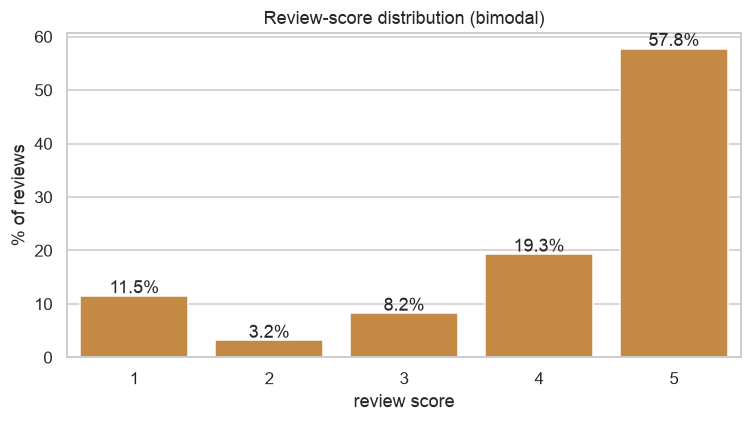

In [11]:
score_dist = reviews.review_score.value_counts(normalize=True).sort_index()
print(f"Mean review score: {reviews.review_score.mean():.2f} / 5")
print(f"5-star share: {score_dist.get(5, 0):.1%} | 1-star share: {score_dist.get(1, 0):.1%}\n")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=score_dist.index, y=score_dist.values * 100, ax=ax, color="#d98b30")
ax.set_title("Review-score distribution (bimodal)")
ax.set_xlabel("review score")
ax.set_ylabel("% of reviews")
for i, v in enumerate(score_dist.values * 100):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

In [12]:
# Does late delivery drive the 1-star tail?
# `order_estimated_delivery_date` is treated as the delivery deadline/limit
# (stored at midnight of the promised day), so any delivery after that instant --
# including later on the same calendar day -- counts as late by design.
delivered = orders[orders.order_status == "delivered"].copy()
delivered["late"] = delivered.order_delivered_customer_date > delivered.order_estimated_delivery_date
dr = delivered.merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")

summary = dr.groupby(dr.late.map({False: "on-time", True: "late"})).agg(
    mean_score=("review_score", "mean"),
    pct_1_star=("review_score", lambda s: (s == 1).mean()),
    orders=("review_score", "size"),
)
print(f"Late deliveries: {delivered.late.mean():.1%} of delivered orders\n")
summary.assign(pct_1_star=lambda d: d.pct_1_star.map("{:.1%}".format)).round(2)

Late deliveries: 8.1% of delivered orders



,mean_score,pct_1_star,orders
late,,,
late,2.57,46.2%,7700
on-time,4.29,6.6%,88661


### 3.1 Does delivery lateness pull the star rating down? (regression)

The cross-tab above suggests late orders are punished. Here we **quantify** it with a simple OLS regression of `review_score` (1–5) on *how slow the delivery felt*, measured two ways:

1. **From purchase** — `days_to_deliver = delivered − purchase` (the absolute wait the customer lived through).
2. **From the promise** — `days_late_vs_eta = delivered − estimated arrival` (>0 = arrived late; <0 = arrived early).

For each we report the slope (stars lost per extra day), its p-value, and R².

In [13]:
# --- 3.1 Regression: does the star rating fall the slower/later a delivery is? ---
import numpy as np
from scipy import stats

reg = (
    orders[orders.order_status == "delivered"]
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")
    .copy()
)
# (a) absolute wait, from purchase to hand-off
reg["days_to_deliver"] = (
    reg.order_delivered_customer_date - reg.order_purchase_timestamp
).dt.total_seconds() / 86_400
# (b) promise miss: >0 = arrived AFTER the estimated date (late), <0 = early
reg["days_late_vs_eta"] = (
    reg.order_delivered_customer_date - reg.order_estimated_delivery_date
).dt.total_seconds() / 86_400
reg = reg.dropna(subset=["review_score", "days_to_deliver", "days_late_vs_eta"])

rows = []
for label, col in [
    ("from purchase (days to deliver)", "days_to_deliver"),
    ("vs estimated ETA (days late)", "days_late_vs_eta"),
]:
    mask = reg[col].notna() & reg.review_score.notna()
    lr = stats.linregress(reg.loc[mask, col], reg.loc[mask, "review_score"])
    rows.append(
        {
            "predictor": label,
            "n_obs": int(mask.sum()),
            "slope (stars/day)": f"{lr.slope:.3f}",
            "intercept": round(lr.intercept, 3),
            "p_value": f"{lr.pvalue:.1e}",
            "R^2": round(lr.rvalue**2, 3),
        }
    )

print(f"n = {len(reg):,} delivered orders with a review")
pd.DataFrame(rows).set_index("predictor")

n = 96,353 delivered orders with a review


,n_obs,slope (stars/day),intercept,p_value,R^2
predictor,,,,,
from purchase (days to deliver),96353,-0.045,4.72,0.0e+00,0.11
vs estimated ETA (days late),96353,-0.034,3.78,0.0e+00,0.07


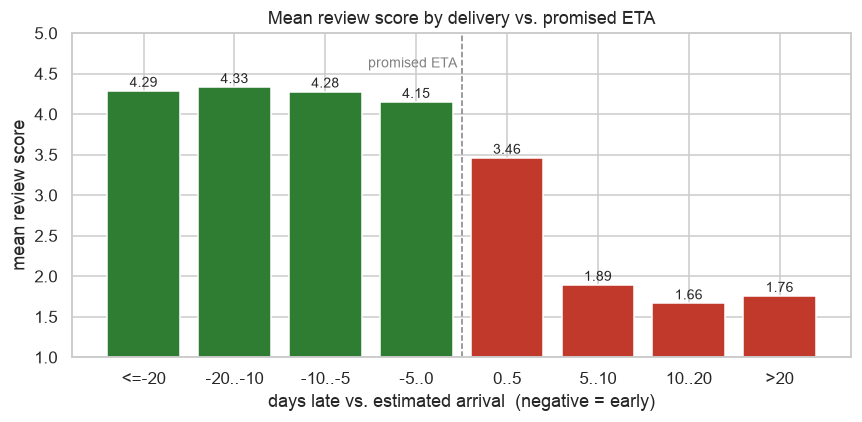

In [14]:
# Why the linear slope understates it: the damage is a *cliff* at the promised date.
bins = [-np.inf, -20, -10, -5, 0, 5, 10, 20, np.inf]
labels = ["<=-20", "-20..-10", "-10..-5", "-5..0", "0..5", "5..10", "10..20", ">20"]
reg["eta_bucket"] = pd.cut(reg.days_late_vs_eta, bins=bins, labels=labels)
by_bucket = reg.groupby("eta_bucket", observed=False).review_score.mean().reindex(labels)

# green = arrived on/before the promise, red = arrived late
colors = ["#2e7d32" if i < 4 else "#c0392b" for i in range(len(by_bucket))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(by_bucket)), by_bucket.values, color=colors)
ax.axvline(3.5, color="gray", ls="--", lw=1)
ax.text(3.45, 4.7, "promised ETA", ha="right", va="top", color="gray", fontsize=9)
ax.set_xticks(range(len(by_bucket)))
ax.set_xticklabels(by_bucket.index)
ax.set_title("Mean review score by delivery vs. promised ETA")
ax.set_xlabel("days late vs. estimated arrival  (negative = early)")
ax.set_ylabel("mean review score")
ax.set_ylim(1, 5)
for i, v in enumerate(by_bucket.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Insight 4 - Missed delivery promises hurt more than long waits

Both slopes are **negative and overwhelmingly significant** (p ≈ 0, n ≈ 96k):

- **From purchase:** ~**−0.045 stars per extra day** of wait (R² ≈ 0.11).
- **Vs. estimated ETA:** ~**−0.034 stars per day late** (R² ≈ 0.07).

But the linear slope *understates* the real story: the relationship is a **cliff, not a ramp**. As the bucket chart shows, orders that arrive **early or on time all sit around 4.2–4.3 stars regardless of how long the wait was** — a slow-but-expected 30-day delivery is fine. The moment an order crosses the **promised date**, the score collapses: **~3.5** stars when 0–5 days late, **~1.9** at 5–10 days, and **~1.7** beyond that.

**Takeaway:** customers don't punish long shipping times per se — they punish **missed promises**. The absolute-wait regression only "works" because long waits correlate with blown ETAs. The lever for review scores is therefore **ETA accuracy / padding the promise**, not raw speed.